In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

100%|██████████| 163M/163M [00:10<00:00, 16.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1


In [2]:
!pip install split-folders

In [3]:
import splitfolders

In [4]:
splitfolders.ratio("/root/.cache/kagglehub/datasets/omkargurav/face-mask-dataset/versions/1/data", ratio=(0.7, .2, .1), output="facemask_detection")

Copying files: 7553 files [00:01, 4740.35 files/s]


**Preprocessing**

In [5]:
import tensorflow as tf

In [6]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/facemask_detection/train",
    image_size=(128, 128),
    batch_size = 32,
    seed = 42)

Found 5286 files belonging to 2 classes.


In [7]:
test_data = tf.keras.utils.image_dataset_from_directory(
    "/content/facemask_detection/test",
    image_size=(128, 128),
    batch_size = 32,
    seed = 42)

Found 757 files belonging to 2 classes.


In [8]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    "/content/facemask_detection/val",
    image_size=(128, 128),
    batch_size = 32,
    seed = 42)

Found 1510 files belonging to 2 classes.


In [9]:
train_data.class_names

['with_mask', 'without_mask']

In [10]:
from PIL import Image
import cv2
from IPython import display

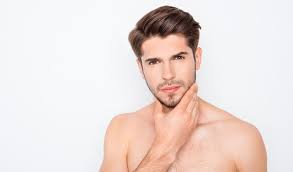

In [11]:
Image.open("/content/facemask_detection/train/without_mask/without_mask_1015.jpg")

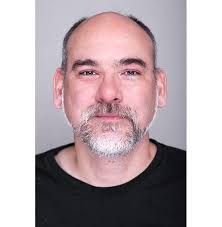

In [12]:
Image.open("/content/facemask_detection/train/without_mask/without_mask_1019.jpg")

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
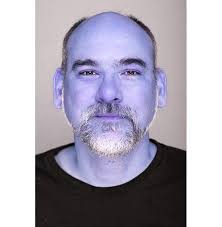

In [13]:
cv2.imread("/content/facemask_detection/train/without_mask/without_mask_1019.jpg")

array([[[171, 183, 193],
        [171, 183, 193],
        [171, 183, 193],
        ...,
        [135, 150, 169],
        [135, 150, 169],
        [134, 149, 168]],

       [[171, 183, 193],
        [171, 183, 193],
        [171, 183, 193],
        ...,
        [135, 150, 169],
        [135, 150, 169],
        [134, 149, 168]],

       [[171, 183, 193],
        [171, 183, 193],
        [171, 183, 193],
        ...,
        [135, 150, 169],
        [135, 150, 169],
        [134, 149, 168]],

       ...,

       [[232, 230, 220],
        [233, 231, 221],
        [234, 232, 222],
        ...,
        [ 92, 115, 137],
        [ 92, 115, 137],
        [ 93, 116, 138]],

       [[232, 230, 220],
        [233, 231, 221],
        [234, 232, 222],
        ...,
        [ 92, 115, 137],
        [ 92, 115, 137],
        [ 93, 116, 138]],

       [[232, 230, 220],
        [233, 231, 221],
        [234, 232, 222],
        ...,
        [ 92, 115, 137],
        [ 92, 115, 137],
        [ 93, 116, 138]]], dtype=uint8)
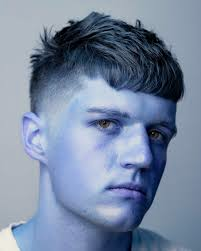

In [14]:
cv2.imread("/content/facemask_detection/train/without_mask/without_mask_1017.jpg")

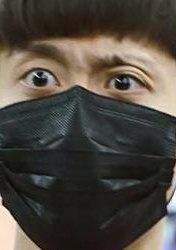

In [15]:
display.Image("/content/facemask_detection/test/with_mask/with_mask_1044.jpg")

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

In [17]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"),   # Feature extract krha tha
    layers.MaxPooling2D((2,2)),


    layers.Flatten(),
    layers.Dense(128, activation="relu"),  ####   Classsify krna
    layers.Dense(1, activation="sigmoid")
])

In [20]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [21]:
model.fit(train_data, epochs=30, validation_data=valid_data)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.5068 - loss: 18.4120 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.5068 - loss: 0.6931 - val_accuracy: 0.5066 - val_loss: 0.6931
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5068 - loss: 0.6931 - val_

In [22]:
!pip install gradio

In [23]:
import numpy as np
import gradio as gr

In [24]:
def predict_image(img):
  img = img.resize((128,128))
  img = np.expand_dims(np.array(img), axis = 0)
  predicton = model.predict(img)[0][0]
  if predicton <0.5:
    return "With mask"
  else:
    return "Without mask"

app=gr.Interface(fn = predict_image, inputs=gr.Image(type="pil"), outputs="text")
app.launch(show_error=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a2030fd5df01362c49.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
data_augmentation= tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)

])

In [26]:
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"),   # Feature extract krha tha
    layers.MaxPooling2D((2,2)),


    layers.Flatten(),
    layers.Dense(128, activation="relu"),  ####   Classsify krna
    layers.Dense(1, activation="sigmoid")
])

In [27]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [28]:
model.fit(train_data, epochs=30, validation_data=valid_data)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7887 - loss: 0.5643 - val_accuracy: 0.8589 - val_loss: 0.3125
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.8628 - loss: 0.3434 - val_accuracy: 0.8709 - val_loss: 0.2919
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.8651 - loss: 0.3287 - val_accuracy: 0.7887 - val_loss: 0.4639
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8560 - loss: 0.3754 - val_accuracy: 0.8861 - val_loss: 0.2693
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.8795 - loss: 0.3014 - val_accuracy: 0.8788 - val_loss: 0.2829
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8890 - loss: 0.2847 - val_accuracy: 0.8907 - val_loss: 0.2622
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8869 - loss: 0.2833 - val_accuracy: 0.8974 - val_loss: 0.2325
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.8931 - loss: 0.2753 - val_

In [29]:
def predict_image(img):
  img = img.resize((128,128))
  img = np.expand_dims(np.array(img), axis = 0)
  predicton = model.predict(img)[0][0]
  if predicton <0.5:
    return "With mask "
  else:
    return "Without mask"

app=gr.Interface(fn = predict_image, inputs=gr.Image(type="pil"), outputs="text")
app.launch(show_error=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d167179498420d922f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
